# Cell Crawling BTP — Version 1

## Phase Field + Actin Polarization + Active Treadmilling

### Goal of Version 1

Version 0 used an artificial prescribed velocity to move the cell.

In Version 1, we introduce the actin polarization field

$$
\mathbf{P}(x,y,t) = (P_x,P_y).
$$

The active treadmilling velocity is now

$$
\boxed{
\mathbf{u}_{active} = w_0\mathbf{P}
}
$$

Therefore, the direction of active transport is determined by the
polarization field rather than being directly hard-coded.

---

### Physics included

- Diffuse cell field $\phi$
- Actin polarization field $\mathbf{P}$
- Active treadmilling $w_0\mathbf{P}$
- Passive phase-field relaxation
- Polarization relaxation

### Not included yet

- Fluid velocity $\mathbf{v}$
- Navier-Stokes solver
- Active stress
- Flow alignment and vorticity coupling
- Substrate slip
- Full 3D model

Version 1 is therefore not a full reproduction of the paper.
It is the next controlled step after Version 0.

## Relation to the paper

The paper uses:

- $f$: cell-material / active-material concentration field
- $\mathbf{P}$: coarse-grained actin polarization
- $\mathbf{v}$: average velocity of cell material and solvent

The paper's polarization equation is

$$
\frac{\partial\mathbf{P}}{\partial t}
+
\left[
(\mathbf{v}+w_0\mathbf{P})\cdot\nabla
\right]\mathbf{P}
=
\mathbf{\Omega}\cdot\mathbf{P}
+
\chi\mathbf{D}\cdot\mathbf{P}
-
\frac{1}{\Gamma}
\frac{\delta F}{\delta\mathbf{P}}.
$$

For Version 1, we deliberately set

$$
\mathbf{v}=0,
\qquad
\mathbf{\Omega}=0,
\qquad
\mathbf{D}=0.
$$

Therefore we use

$$
\boxed{
\frac{\partial\mathbf{P}}{\partial t}
+
(w_0\mathbf{P}\cdot\nabla)\mathbf{P}
=
-\frac{1}{\Gamma}
\frac{\delta F}{\delta\mathbf{P}}
}
$$

We will add the fluid velocity and hydrodynamic coupling later.

# 1. Imports and simulation parameters

The new parameters in Version 1 are:

- `w0`: strength of active treadmilling
- `polar_relaxation`: how strongly polarization relaxes
- `polar_elasticity`: penalizes rapid changes in polarization
- `polar_strength`: controls the polarization magnitude
- `noise_strength`: creates a small perturbation in the initial
  polarization field

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Cell Crawling BTP — Version 1
#
# Physics:
#
#   phi(x,y,t) : diffuse cell field
#   P(x,y,t)   : actin polarization
#   w0 * P     : active treadmilling velocity
#
# ============================================================


N = 160
L = 80.0
dx = L / N

dt = 0.001
steps = 5000


# Cell parameters
radius = 18.0
interface_width = 2.0


# Passive phase-field relaxation
phi_relaxation = 0.5


# Actin treadmilling strength
w0 = 1.0


# Polarization parameters
polar_relaxation = 0.8
polar_elasticity = 1.0
polar_strength = 1.0


# Optional boundary anchoring
anchoring = 0.0


# Small initial perturbation
noise_strength = 0.02


snapshot_steps = [0,1000,2000,3000,4000,4999]

# 2. Spatial derivatives

The equations contain spatial derivatives of both the cell field and
the polarization field.

We therefore need:

$$
\nabla \phi,
\qquad
\nabla^2\phi,
\qquad
\nabla P_x,
\qquad
\nabla P_y.
$$

We use the same central finite-difference method used in Version 0.

In [ ]:
def gradient_x(a):
    return (np.roll(a, -1, axis=0)- np.roll(a, 1, axis=0)) / (2.0 * dx)


def gradient_y(a):
    return (np.roll(a, -1, axis=1)- np.roll(a, 1, axis=1)) / (2.0 * dx)


def laplacian(a):
    return (np.roll(a, 1, axis=0)+ np.roll(a, -1, axis=0)+ np.roll(a, 1, axis=1)+ np.roll(a, -1, axis=1)- 4.0 * a) / dx**2

# 3. Initial cell

As in Version 0:

$$
\phi \approx 1
$$

inside the cell and

$$
\phi \approx 0
$$

outside the cell.

We use a `tanh` profile to create a smooth diffuse interface.

In [ ]:
def initialize_phase_field(X, Y):

    r = np.sqrt(X**2 + Y**2)

    return 0.5 * (1.0- np.tanh((r - radius)/ (np.sqrt(2.0) * interface_width)))

# 4. Initial actin polarization

The new field is

$$
\boxed{
\mathbf{P}=(P_x,P_y)
}
$$

At every location, the vector $\mathbf{P}$ gives the local direction
of actin polarization.

For this first Version 1 prototype, we initialize the polarization
mostly toward the $+x$ direction:

$$
\mathbf{P}\approx(1,0).
$$

A small perturbation is added so that the polarization is not perfectly
uniform.

This is still an initial condition. We are not yet modeling spontaneous
selection of the crawling direction.

In [ ]:
def initialize_polarization(X, Y, phi):

    rng = np.random.default_rng(7)

    Px = phi * (1.0+ noise_strength* rng.standard_normal(phi.shape))

    Py = phi * (noise_strength* rng.standard_normal(phi.shape))

    magnitude = np.sqrt(Px**2 + Py**2) + 1e-12

    # Normalize polarization inside the cell
    Px = phi * Px / magnitude
    Py = phi * Py / magnitude

    return Px, Py

# 5. Polarization free-energy derivative

The polarization field also needs its own restoring physics.

We use a simplified $\delta F/\delta\mathbf{P}$ containing:

### 1. Bulk polarization

This allows the cell interior to maintain a nonzero polarization.

### 2. Magnitude stabilization

The nonlinear term

$$
|\mathbf{P}|^2\mathbf{P}
$$

prevents the magnitude of polarization from growing indefinitely.

### 3. Polarization elasticity

The term

$$
-\kappa\nabla^2\mathbf{P}
$$

penalizes rapid spatial changes in polarization.

Therefore nearby regions tend to have similar polarization directions.

### 4. Boundary anchoring

The full model can couple polarization to the cell boundary.

For this first prototype:

$$
\texttt{anchoring}=0
$$

so we do not yet study that effect.

In [ ]:
def polarization_chemical_force(Px,Py,phi):

    p2 = Px**2 + Py**2

    # Active region
    t = (phi > 0.5).astype(float)

    f_cr = 0.5

    bulk_coefficient = (-polar_strength* (t - f_cr)/ f_cr)

    dF_dPx = (bulk_coefficient * Px + polar_strength * p2 * Px - polar_elasticity * laplacian(Px) + anchoring * gradient_x(phi))

    dF_dPy = (bulk_coefficient * Py + polar_strength * p2 * Py- polar_elasticity * laplacian(Py)+ anchoring * gradient_y(phi))

    return dF_dPx, dF_dPy

# 6. The coupled Version 1 equations

The active velocity is now determined by the polarization:

$$
\boxed{
u_x=w_0P_x,
\qquad
u_y=w_0P_y
}
$$

This is the main conceptual change from Version 0.

---

## Cell-field equation

We use

$$
\boxed{
\frac{\partial\phi}{\partial t}
+
(w_0\mathbf{P})\cdot\nabla\phi
=
-\lambda\mu_\phi
}
$$

where

$$
\mu_\phi
=
-\epsilon^2\nabla^2\phi
+
\phi(\phi-1)(2\phi-1).
$$

The first term represents active transport.

The second term represents passive phase-field relaxation.

---

## Polarization equation

We use

$$
\boxed{
\frac{\partial\mathbf{P}}{\partial t}
+
(w_0\mathbf{P}\cdot\nabla)\mathbf{P}
=
-\text{polar relaxation}
\cdot
\frac{\delta F}{\delta\mathbf{P}}
}
$$

Therefore the physical feedback is

$$
\boxed{
\mathbf{P}
\rightarrow
w_0\mathbf{P}
\rightarrow
\text{active transport}
\rightarrow
\text{cell motion}
}
$$

In [ ]:
def run_simulation():

    x = np.linspace(-L / 2.0,L / 2.0,N)

    y = np.linspace(-L / 2.0,L / 2.0,N)

    X, Y = np.meshgrid(x,y,indexing="ij")


    # =========================================================
    # Initial fields
    # =========================================================

    phi = initialize_phase_field(X,Y)


    Px, Py = initialize_polarization(X,Y,phi)


    # =========================================================
    # Snapshots
    # =========================================================

    snapshots = []


    # =========================================================
    # Diagnostics storage
    # =========================================================

    diagnostics = {

        "time": [],

        "mass": [],

        "x_cm": [],
        "y_cm": [],

        "major_axis": [],
        "minor_axis": [],
        "aspect_ratio": [],

        "avg_Px": [],
        "avg_Py": [],

        "polarization_order": [],

        "avg_P_magnitude": [],

        "active_velocity": [],

        "passive_energy": []
    }


    # =========================================================
    # Time evolution
    # =========================================================

    for step in range(steps):


        # =====================================================
        # A. Active treadmilling velocity
        #
        # u_active = w0 * P
        # =====================================================

        ux = w0 * Px

        uy = w0 * Py


        # =====================================================
        # B. Update cell field phi
        #
        # dphi/dt = - (u_active . grad) phi - phi_relaxation * mu_phi
        # =====================================================

        dphi_dx = gradient_x(phi)

        dphi_dy = gradient_y(phi)

        advection_phi = (ux * dphi_dx + uy * dphi_dy)

        # =====================================================


        chemical_potential_phi = (-interface_width**2 * laplacian(phi) + phi * (phi - 1.0) * (2.0 * phi - 1.0))

        phi += dt * (-advection_phi - phi_relaxation * chemical_potential_phi)

        phi = np.clip(phi,0.0,1.0)

        # =====================================================
        # C. Update polarization Px, Py
        # =====================================================

        dPx_dx = gradient_x(Px)

        dPx_dy = gradient_y(Px)

        dPy_dx = gradient_x(Py)

        dPy_dy = gradient_y(Py)


        active_advection_Px = (ux * dPx_dx + uy * dPx_dy)

        active_advection_Py = (ux * dPy_dx + uy * dPy_dy)

        dF_dPx, dF_dPy = (polarization_chemical_force(Px,Py,phi))

        Px += dt * (-active_advection_Px - polar_relaxation * dF_dPx)

        Py += dt * (-active_advection_Py - polar_relaxation * dF_dPy)


        # =====================================================
        # Numerical safety limit
        # =====================================================

        magnitude = np.sqrt(Px**2 + Py**2)


        mask = magnitude > 1.5


        Px[mask] *= (1.5/magnitude[mask])


        Py[mask] *= (1.5/magnitude[mask])


        # =====================================================
        # D. Record diagnostics
        # =====================================================

        if step % 10 == 0:

            data = calculate_diagnostics(phi,Px,Py,X,Y)

            diagnostics["time"].append(step * dt)

            for key in data:
                diagnostics[key].append(data[key])


        # =====================================================
        # E. Save snapshots
        # =====================================================

        if step in snapshot_steps:
            snapshots.append((step,phi.copy(),Px.copy(),Py.copy()))


    # =========================================================
    # Convert diagnostics to numpy arrays
    # =========================================================

    for key in diagnostics:
        diagnostics[key] = np.array(diagnostics[key])


    # =========================================================
    # Calculate center-of-mass velocity
    # =========================================================

    time = diagnostics["time"]


    diagnostics["Vx"] = np.gradient(diagnostics["x_cm"],time)

    diagnostics["Vy"] = np.gradient(diagnostics["y_cm"],time)


    diagnostics["speed"] = np.sqrt(diagnostics["Vx"]**2 + diagnostics["Vy"]**2)


    return (X,Y,snapshots,diagnostics)

# 7. Visualization

The background represents the cell phase field $\phi$.

The arrows represent the local actin polarization:

$$
\mathbf{P}=(P_x,P_y).
$$

Since the active treadmilling velocity is

$$
\mathbf{u}_{active}=w_0\mathbf{P},
$$

the arrows also indicate the local direction of active transport.

In [ ]:
def plot_results(X,Y,snapshots):

    fig, axes = plt.subplots(2,3,figsize=(13, 8))

    for ax, (step,phi,Px,Py) in zip(axes.flat,snapshots):

        ax.imshow(phi.T,origin="lower",

            extent=[
                X.min(),
                X.max(),
                Y.min(),
                Y.max()
            ],

            vmin=0.0,
            vmax=1.0
        )

        stride = 8

        ax.quiver(
            X[::stride, ::stride],
            Y[::stride, ::stride],

            Px[::stride, ::stride],
            Py[::stride, ::stride],

            color="white",

            scale=25,

            width=0.0025
        )


        ax.set_title(f"step = {step}")

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        ax.set_aspect("equal")


    fig.suptitle("Version 1: " "Cell + Actin Polarization " "+ Treadmilling")

    fig.tight_layout()

    plt.show()

# 8. Quantitative diagnostics

Cell snapshots show the shape of the cell at selected times.

However, to understand the dynamics of the simulation, we also measure
physical quantities throughout the simulation.

The main quantities are:

### Cell position

$$
x_{cm}
=
\frac{\int x\phi\,dA}
{\int\phi\,dA}
$$

$$
y_{cm}
=
\frac{\int y\phi\,dA}
{\int\phi\,dA}
$$

These tell us whether the cell is translating.

---

### Cell area

The effective cell area is

$$
A
=
\int\phi\,dA.
$$

For a stable cell, this should not change dramatically.

---

### Cell velocity

The cell velocity is calculated from the change of the center of mass:

$$
V_x
=
\frac{dx_{cm}}{dt},
\qquad
V_y
=
\frac{dy_{cm}}{dt}.
$$

---

### Cell shape

The second moments of the phase field are used to estimate the
principal dimensions of the cell.

This allows us to calculate an approximate aspect ratio:

$$
\text{aspect ratio}
=
\frac{\text{major axis}}
{\text{minor axis}}.
$$

A value close to 1 corresponds to a roughly circular cell.

---

### Average polarization

The cell-averaged polarization is

$$
\langle P_x\rangle,
\qquad
\langle P_y\rangle.
$$

The magnitude of the average polarization is

$$
\boxed{
P_{\text{order}}
=
\sqrt{
\langle P_x\rangle^2
+
\langle P_y\rangle^2
}
}
$$

This tells us how strongly aligned the polarization is across the cell.

---

### Active treadmilling velocity

Since

$$
\mathbf u_{\text{active}}
=
w_0\mathbf P,
$$

we calculate

$$
\langle |\mathbf u_{\text{active}}| \rangle
=
w_0
\langle |\mathbf P| \rangle.
$$

This directly measures the strength of active transport.

In [ ]:
def calculate_diagnostics(phi,Px,Py,X,Y):

    # =========================================================
    # 1. Effective cell mass / area
    # =========================================================

    mass = np.sum(phi)


    # =========================================================
    # 2. Center of mass
    # =========================================================

    x_cm = np.sum(X * phi) / mass

    y_cm = np.sum(Y * phi) / mass


    # =========================================================
    # 3. Second moments
    #
    # Used to estimate cell elongation
    # =========================================================

    Xc = X - x_cm
    Yc = Y - y_cm


    Mxx = np.sum(Xc**2 * phi) / mass


    Myy = np.sum(Yc**2 * phi) / mass


    Mxy = np.sum(Xc * Yc * phi) / mass


    covariance = np.array([[Mxx, Mxy],[Mxy, Myy]])


    eigenvalues = np.linalg.eigvalsh(covariance)


    minor_axis = np.sqrt(max(eigenvalues[0], 1e-12))


    major_axis = np.sqrt(max(eigenvalues[1], 1e-12))


    aspect_ratio = (major_axis / minor_axis)


    # =========================================================
    # 4. Polarization diagnostics
    #
    # Calculate only inside the cell.
    # phi is used as a weight.
    # =========================================================

    avg_Px = np.sum(Px * phi) / mass


    avg_Py = np.sum(Py * phi) / mass


    polarization_order = np.sqrt(avg_Px**2 + avg_Py**2)


    # Local polarization magnitude
    P_magnitude = np.sqrt(Px**2 + Py**2)


    avg_P_magnitude = np.sum(P_magnitude * phi) / mass


    # =========================================================
    # 5. Active velocity
    #
    # u_active = w0 * P
    # =========================================================

    active_velocity_magnitude = (w0 * avg_P_magnitude)


    # =========================================================
    # 6. Passive phase-field energy
    #
    # F =
    # integral[
    #   epsilon^2/2 |grad phi|^2
    #   +
    #   1/2 phi^2 (1-phi)^2
    # ]
    # =========================================================

    grad_phi_x = gradient_x(phi)
    grad_phi_y = gradient_y(phi)


    gradient_energy = (0.5 * interface_width**2 * (grad_phi_x**2 + grad_phi_y**2))


    bulk_energy = (0.5 * phi**2 * (1.0 - phi)**2)


    passive_energy = np.sum(gradient_energy + bulk_energy)


    return {
        "mass": mass,

        "x_cm": x_cm,
        "y_cm": y_cm,

        "major_axis": major_axis,
        "minor_axis": minor_axis,

        "aspect_ratio": aspect_ratio,

        "avg_Px": avg_Px,
        "avg_Py": avg_Py,

        "polarization_order": (
            polarization_order
        ),

        "avg_P_magnitude": (
            avg_P_magnitude
        ),

        "active_velocity": (
            active_velocity_magnitude
        ),

        "passive_energy": (
            passive_energy
        )
    }

# 9. Cell velocity

The active velocity field

$$
\mathbf u_{\text{active}}
=
w_0\mathbf P
$$

is the velocity used to transport the phase field locally.

However, this is not necessarily identical to the velocity of the
entire cell.

The actual cell velocity is measured from the center of mass:

$$
V_x
=
\frac{dx_{cm}}{dt}
$$

and

$$
V_y
=
\frac{dy_{cm}}{dt}.
$$

This distinction is important:

$$
\boxed{
\text{local active material velocity}
\neq
\text{necessarily whole-cell velocity}
}
$$

The cell can have internal active motion without translating as a
whole.

Therefore both quantities are plotted.

In [ ]:
def plot_diagnostics(diagnostics):

    time = diagnostics["time"]


    # =========================================================
    # Figure 1
    #
    # Cell center of mass
    # =========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(time,diagnostics["x_cm"],label="x_cm")

    plt.plot(time,diagnostics["y_cm"],label="y_cm")

    plt.xlabel("Time")

    plt.ylabel("Center of mass")

    plt.title("Cell Center of Mass")

    plt.legend()

    plt.grid()

    plt.show()


    # =========================================================
    # Figure 2
    #
    # Cell velocity
    # =========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(time,diagnostics["Vx"],label="Vx")

    plt.plot(time,diagnostics["Vy"],label="Vy")

    plt.plot(time,diagnostics["speed"],label="Speed")

    plt.xlabel("Time")

    plt.ylabel("Cell velocity")

    plt.title("Whole-Cell Velocity")

    plt.legend()

    plt.grid()

    plt.show()


    # =========================================================
    # Figure 3
    #
    # Effective cell area / mass
    # =========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(time,diagnostics["mass"])

    plt.xlabel("Time")

    plt.ylabel("Effective cell area")

    plt.title("Cell Area Stability")

    plt.grid()

    plt.show()


    # =========================================================
    # Figure 4
    #
    # Cell shape
    # =========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(time,diagnostics["aspect_ratio"])

    plt.xlabel("Time")

    plt.ylabel("Major axis / minor axis")

    plt.title("Cell Aspect Ratio")

    plt.grid()

    plt.show()


    # =========================================================
    # Figure 5
    #
    # Average polarization components
    # =========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(time,diagnostics["avg_Px"],label="<Px>")

    plt.plot(time,diagnostics["avg_Py"],label="<Py>")

    plt.xlabel("Time")

    plt.ylabel("Average polarization")

    plt.title("Average Polarization Components")

    plt.legend()

    plt.grid()

    plt.show()


    # =========================================================
    # Figure 6
    #
    # Polarization order
    # =========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(time,diagnostics["polarization_order"],label="|<P>|")

    plt.plot(time,diagnostics["avg_P_magnitude"],label="<|P|>")

    plt.xlabel("Time")

    plt.ylabel("Polarization magnitude")

    plt.title("Polarization Strength and Alignment")

    plt.legend()

    plt.grid()

    plt.show()


    # =========================================================
    # Figure 7
    #
    # Active velocity
    # =========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(time,diagnostics["active_velocity"])

    plt.xlabel("Time")

    plt.ylabel("<|w0 P|>")

    plt.title("Average Active Treadmilling Velocity")

    plt.grid()

    plt.show()


    # =========================================================
    # Figure 8
    #
    # Passive phase-field energy
    # =========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(time,diagnostics["passive_energy"])

    plt.xlabel("Time")

    plt.ylabel("Passive free energy")

    plt.title("Passive Phase-Field Energy")

    plt.grid()

    plt.show()

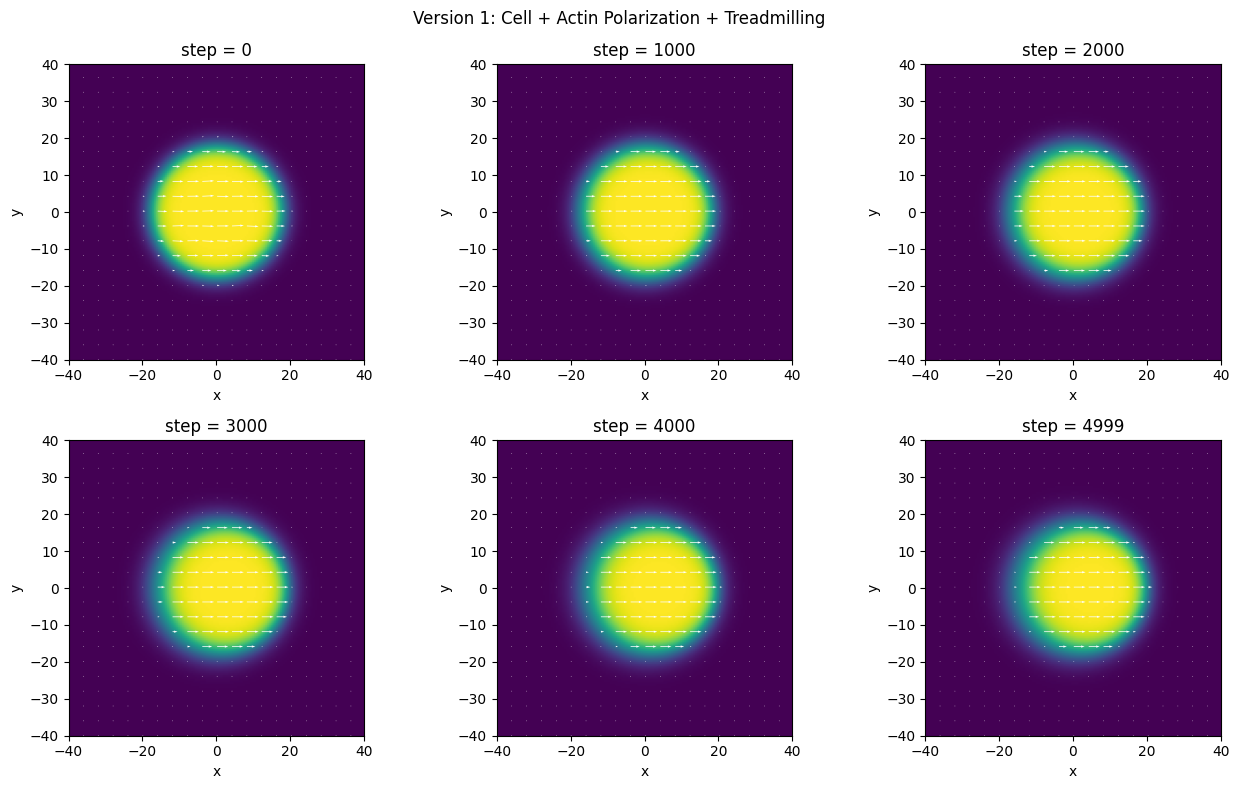

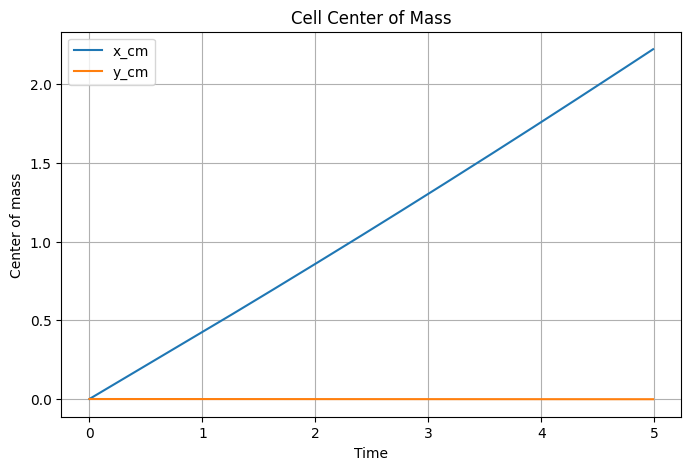

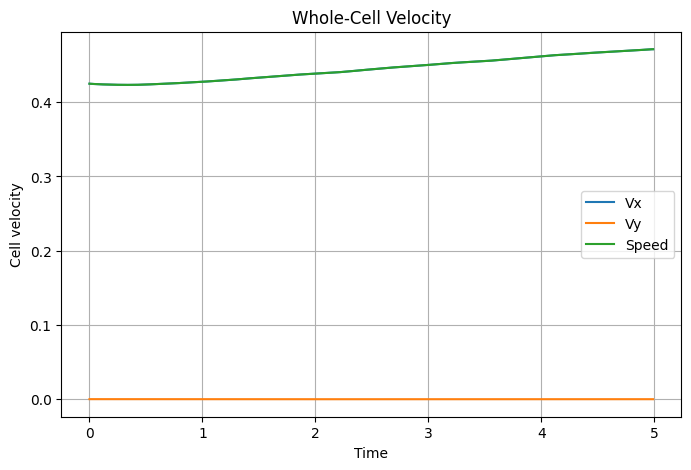

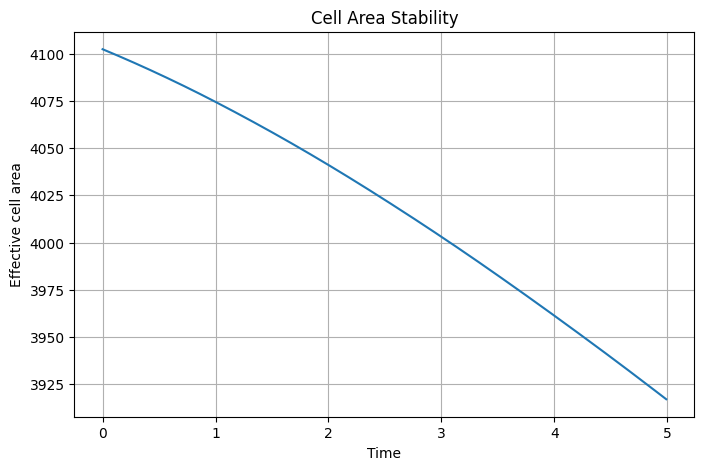

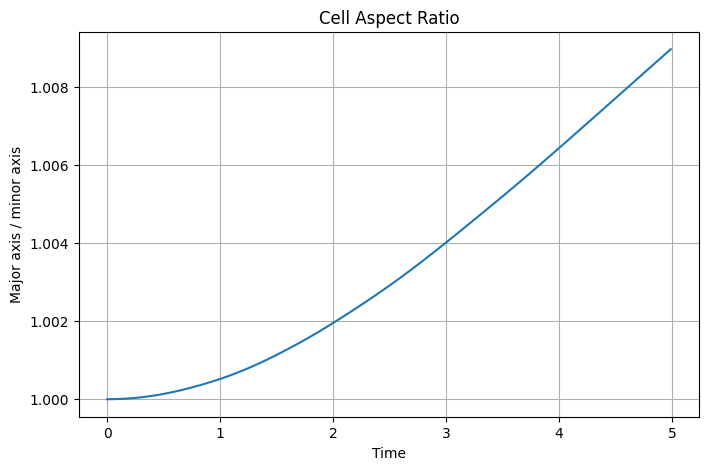

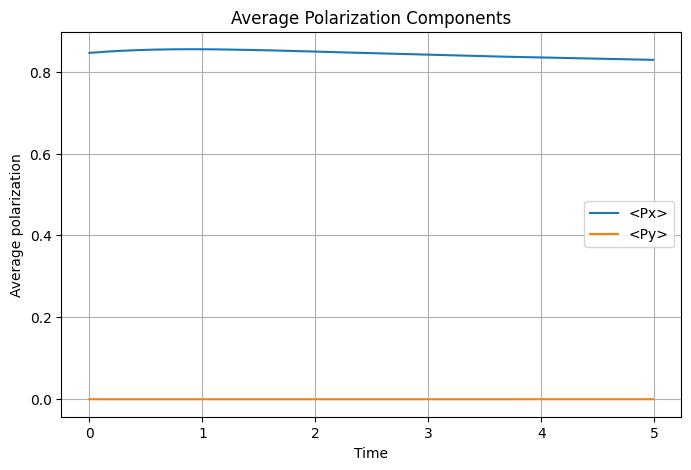

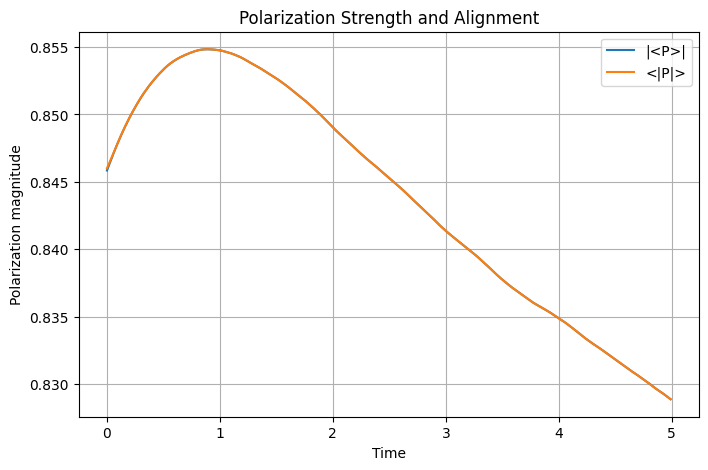

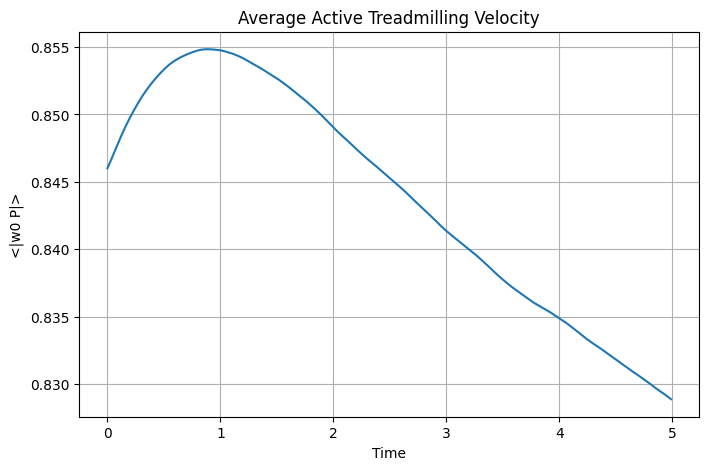

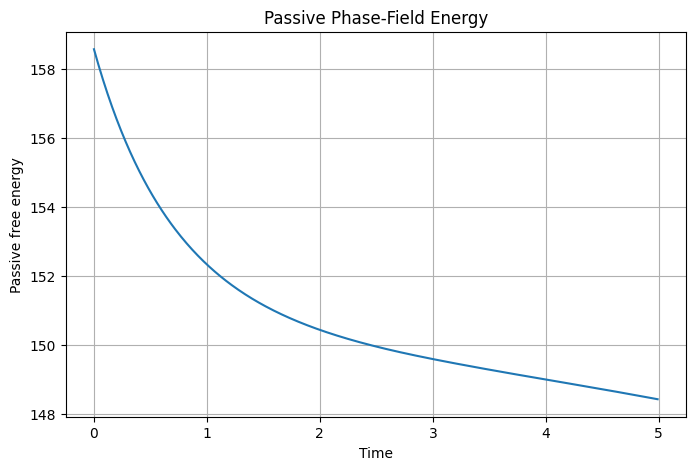

In [ ]:
X, Y, snapshots, diagnostics = (run_simulation())

plot_results(X,Y,snapshots)

plot_diagnostics(diagnostics)